# Notebook 2.2 — Multi-Asset `GenWealthEnv` (Gymnasium)

**Purpose:** Define `MultiAssetGenWealthEnv` — a Gymnasium-compliant MDP for
*multi-asset portfolio allocation* across 4 stocks + a Cash position.

This refined version includes **scaled daily returns** and **re-calibrated penalties**.

## MDP Design

| Component | Design |
|-----------|--------|
| **Assets** | `HDFCBANK.NS`, `NVDA`, `RELIANCE.NS`, `TCS.NS` + Cash |
| **State S_t** | 65-dim flat vector: `[4 assets x 15 features] + [5 current weights]` |
| **Action A_t** | Raw logits `Box(-3, 3, shape=(5,))` -> **Softmax** -> weights sum_i w_i = 1 |
| **Reward R_t** | `100 * r_t - lambda*d_t - gamma*tau_t` (scaled return - drawdown penalty - turnover penalty) |
| **Episode** | One full pass through all aligned multi-asset trading dates |

## Refined Reward Calibration

| Parameter | Previous Value | Refined Value | Rationale |
|-----------|----------------|---------------|-----------|
| **Return Scale** | 1.0 | **100.0** | Daily returns (~0.001) now produce meaningful +0.1 to +1.0 signals |
| **Drawdown Penalty (lambda)** | 0.1 | **0.02** | Prevents panic selling / permanent defensive cash lock-up |
| **Turnover Penalty (gamma)** | 0.002 | **0.0005** | Penalizes high-frequency churn without preventing strategic rebalancing |

In [1]:
# CELL 1: IMPORTS
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from stable_baselines3.common.env_checker import check_env

print("Cell 1 done: imports loaded.")
print(f"  gymnasium version : {gym.__version__}")

Cell 1 done: imports loaded.
  gymnasium version : 1.3.0


In [2]:
# CELL 2: GLOBAL CONFIGURATION
TICKERS = ['HDFCBANK.NS', 'NVDA', 'RELIANCE.NS', 'TCS.NS']   # sorted alphabetically
N_ASSETS = len(TICKERS)   # 4
N_ACT    = N_ASSETS + 1   # 5  (4 stocks + 1 cash slot)

FEATURE_COLS = [
    'Log_Ret',   'Vol_20',    'Vol_Ratio',
    'Ret_1M',    'Ret_3M',    'Efficiency', 'Vol_Shock',
    'Ret_Lag1',  'Ret_Lag2',  'Ret_Lag3',
    'Ret_Lag5',  'Ret_Lag10', 'Ret_Lag20',
    'Sentiment', 'Phase1_Signal',
]
N_FEAT_PER_ASSET = len(FEATURE_COLS)            # 15
N_OBS_FEAT       = N_ASSETS * N_FEAT_PER_ASSET  # 60
OBS_DIM          = N_OBS_FEAT + N_ACT           # 65

INITIAL_BALANCE  = 100_000.0
TRANSACTION_COST = 0.001      # 0.1% of portfolio value per unit of turnover
REWARD_SCALE     = 100.0      # Scale return by 100 (1% daily ret -> +1.0 reward)
LAMBDA_DD        = 0.02       # drawdown penalty coefficient lambda (reduced from 0.1)
GAMMA_TO         = 0.0005     # turnover penalty coefficient gamma (reduced from 0.002)

DATA_DIR  = "../data"             if os.path.basename(os.getcwd()) == "notebooks" else "data"
ART_DIR   = "../model_artifacts"  if os.path.basename(os.getcwd()) == "notebooks" else "model_artifacts"
DATA_PATH = os.path.join(DATA_DIR, "enriched_rl_data.csv")

print("Cell 2 done: Configuration loaded.")
print(f"  TICKERS          : {TICKERS}")
print(f"  OBS_DIM          : {OBS_DIM}  ({N_ASSETS}x{N_FEAT_PER_ASSET} features + {N_ACT} weights)")
print(f"  ACT_DIM          : {N_ACT}  (raw logits Box(-3,3) -> softmax -> portfolio weights)")
print(f"  INITIAL_BALANCE  : {INITIAL_BALANCE:,.0f}")
print(f"  TRANSACTION_COST : {TRANSACTION_COST*100:.1f}% per unit turnover")
print(f"  Reward Scale     : {REWARD_SCALE}x")
print(f"  lambda (drawdown): {LAMBDA_DD}")
print(f"  gamma  (turnover): {GAMMA_TO}")

Cell 2 done: Configuration loaded.
  TICKERS          : ['HDFCBANK.NS', 'NVDA', 'RELIANCE.NS', 'TCS.NS']
  OBS_DIM          : 65  (4x15 features + 5 weights)
  ACT_DIM          : 5  (raw logits Box(-3,3) -> softmax -> portfolio weights)
  INITIAL_BALANCE  : 100,000
  TRANSACTION_COST : 0.1% per unit turnover
  Reward Scale     : 100.0x
  lambda (drawdown): 0.02
  gamma  (turnover): 0.0005


In [3]:
# CELL 3: LOAD RAW DATA & PIVOT TO WIDE FORMAT
print("Loading enriched RL data...")
raw_df = pd.read_csv(DATA_PATH, index_col="Date", parse_dates=True)
raw_df.sort_index(inplace=True)
raw_df.dropna(inplace=True)
print(f"  Raw shape    : {raw_df.shape}")
print(f"  Tickers found: {sorted(raw_df['Ticker'].unique())}")

feat_pivot = (
    raw_df[FEATURE_COLS + ['Ticker']]
    .reset_index()
    .pivot_table(index='Date', columns='Ticker', values=FEATURE_COLS, aggfunc='first')
)
feat_pivot = feat_pivot.swaplevel(axis=1).sort_index(axis=1)
feat_pivot.dropna(inplace=True)

LOG_RET_INDICES = [
    i for i, (ticker, feat) in enumerate(feat_pivot.columns) if feat == 'Log_Ret'
]
LOG_RET_TICKER_ORDER = [
    ticker for (ticker, feat) in feat_pivot.columns if feat == 'Log_Ret'
]

feat_pivot.columns = [f"{t}__{f}" for t, f in feat_pivot.columns]

price_pivot = (
    raw_df[['Ticker', 'Close_Price']]
    .reset_index()
    .pivot_table(index='Date', columns='Ticker', values='Close_Price', aggfunc='first')
    [TICKERS]
    .loc[feat_pivot.index]
)

print(f"\nCell 3 done: Data pivoted.")
print(f"  Feature matrix shape : {feat_pivot.shape}  (T x {N_ASSETS}x{N_FEAT_PER_ASSET})")
print(f"  Price matrix shape   : {price_pivot.shape}  (T x {N_ASSETS})")
print(f"  Date range           : {feat_pivot.index[0].date()} -> {feat_pivot.index[-1].date()}")
print(f"  Log_Ret indices      : {LOG_RET_INDICES}  (for tickers: {LOG_RET_TICKER_ORDER})")
feat_pivot.head(2)

Loading enriched RL data...
  Raw shape    : (15434, 19)
  Tickers found: ['HDFCBANK.NS', 'NVDA', 'RELIANCE.NS', 'TCS.NS']

Cell 3 done: Data pivoted.
  Feature matrix shape : (3720, 60)  (T x 4x15)
  Price matrix shape   : (3720, 4)  (T x 4)
  Date range           : 2011-01-18 -> 2026-08-07
  Log_Ret indices      : [1, 16, 31, 46]  (for tickers: ['HDFCBANK.NS', 'NVDA', 'RELIANCE.NS', 'TCS.NS'])


,HDFCBANK.NS__Efficiency,HDFCBANK.NS__Log_Ret,HDFCBANK.NS__Phase1_Signal,HDFCBANK.NS__Ret_1M,HDFCBANK.NS__Ret_3M,HDFCBANK.NS__Ret_Lag1,HDFCBANK.NS__Ret_Lag10,HDFCBANK.NS__Ret_Lag2,HDFCBANK.NS__Ret_Lag20,HDFCBANK.NS__Ret_Lag3,...,TCS.NS__Ret_Lag1,TCS.NS__Ret_Lag10,TCS.NS__Ret_Lag2,TCS.NS__Ret_Lag20,TCS.NS__Ret_Lag3,TCS.NS__Ret_Lag5,TCS.NS__Sentiment,TCS.NS__Vol_20,TCS.NS__Vol_Ratio,TCS.NS__Vol_Shock
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-18,0.122051,0.019749,0.531376,-0.047311,-0.108135,0.009010,-0.018983,-0.044586,0.018968,-0.028657,...,0.015282,-0.011551,-0.003654,-0.005070,-0.010353,-0.029068,0.197400,0.019143,1.121742,2.916418
2011-01-19,0.120617,-0.016202,0.523563,-0.047435,-0.107967,0.019749,-0.016052,0.009010,-0.016072,-0.044586,...,0.055699,0.012328,0.015282,-0.009566,-0.003654,0.033524,0.036029,0.019097,1.118040,1.010206


In [4]:
# CELL 4: DATA VALIDATION ASSERTIONS
assert feat_pivot.shape[1] == N_OBS_FEAT, f"Feature column count mismatch: got {feat_pivot.shape[1]}, expected {N_OBS_FEAT}"
assert price_pivot.shape[1] == N_ASSETS, f"Price matrix ticker count mismatch: {price_pivot.shape[1]} vs {N_ASSETS}"
assert len(LOG_RET_INDICES) == N_ASSETS, f"Log_Ret index count mismatch: {len(LOG_RET_INDICES)} vs {N_ASSETS}"
assert not feat_pivot.isnull().any().any(), "NaNs detected in feature matrix!"
assert not price_pivot.isnull().any().any(), "NaNs detected in price matrix!"

print("Cell 4 done: All data validation assertions PASSED.")
print(f"  Total aligned trading days : {len(feat_pivot):,}")
print(f"  NaN values in features     : 0 (PASS)")
print(f"  NaN values in prices       : 0 (PASS)")

Cell 4 done: All data validation assertions PASSED.
  Total aligned trading days : 3,720
  NaN values in features     : 0 (PASS)
  NaN values in prices       : 0 (PASS)


In [5]:
# CELL 5: MultiAssetGenWealthEnv CLASS DEFINITION
class MultiAssetGenWealthEnv(gym.Env):
    """
    Multi-Asset Portfolio Allocation Environment — GenWealth Phase 2.

    MDP Specification
    -----------------
    State  S_t : flat float32 vector, shape (OBS_DIM,) = (65,)
                 = [per-asset features (60)] + [current portfolio weights (5)]

    Action A_t : raw logits, shape (N_ACT,) = (5,) in Box(-3, 3)
                 -> softmax inside step() -> portfolio weight simplex (sum w_i = 1)

    Reward R_t : 100 * r_t  -  lambda*d_t  -  gamma*tau_t
                 r_t    = daily portfolio return (fraction)
                 d_t    = current drawdown from running peak (0 when at or above peak)
                 tau_t  = total turnover = sum|delta w_i|
                 reward_scale = 100.0
                 lambda = lambda_dd  (default 0.02)
                 gamma  = gamma_to   (default 0.0005)
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        feat_array,
        log_ret_indices,
        n_assets=4,
        initial_balance=100_000.0,
        transaction_cost=0.001,
        reward_scale=100.0,
        lambda_dd=0.02,
        gamma_to=0.0005,
    ):
        super().__init__()

        self.feat_array       = np.asarray(feat_array, dtype=np.float32)
        self.log_ret_indices  = np.asarray(log_ret_indices, dtype=np.int32)
        self.n_assets         = n_assets
        self.n_act            = n_assets + 1
        self.n_steps          = len(feat_array)
        self.initial_balance  = float(initial_balance)
        self.tc               = float(transaction_cost)
        self.reward_scale     = float(reward_scale)
        self.lambda_dd        = float(lambda_dd)
        self.gamma_to         = float(gamma_to)

        self.action_space = spaces.Box(
            low=-3.0, high=3.0, shape=(self.n_act,), dtype=np.float32
        )

        obs_dim = self.feat_array.shape[1] + self.n_act
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        self.current_step    = 0
        self.portfolio_value = self.initial_balance
        self.current_weights = np.zeros(self.n_act, dtype=np.float32)
        self.peak_value      = self.initial_balance
        self.portfolio_values = []
        self.weight_history  = []

    def _softmax(self, logits):
        x = np.asarray(logits, dtype=np.float64)
        e = np.exp(x - x.max())
        return (e / e.sum()).astype(np.float32)

    def _get_obs(self):
        features = self.feat_array[self.current_step]
        return np.concatenate([features, self.current_weights], dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = 0
        self.portfolio_value = self.initial_balance
        self.peak_value      = self.initial_balance
        self.current_weights = np.array([0.0] * self.n_assets + [1.0], dtype=np.float32)
        self.portfolio_values = [self.initial_balance]
        self.weight_history  = [self.current_weights.copy()]
        return self._get_obs(), {}

    def step(self, action):
        logits         = np.clip(action, -3.0, 3.0)
        target_weights = self._softmax(logits)

        turnover = float(np.sum(np.abs(target_weights - self.current_weights)))
        cost     = turnover * self.portfolio_value * self.tc
        self.portfolio_value -= cost

        next_step = self.current_step + 1
        if next_step >= self.n_steps:
            next_step = self.n_steps - 1

        asset_log_rets    = self.feat_array[next_step][self.log_ret_indices]
        asset_simple_rets = np.exp(asset_log_rets.astype(np.float64)) - 1.0

        stock_weights = target_weights[:self.n_assets].astype(np.float64)
        port_return   = float(np.dot(stock_weights, asset_simple_rets))

        self.portfolio_value = max(self.portfolio_value * (1.0 + port_return), 1.0)
        self.peak_value      = max(self.peak_value, self.portfolio_value)
        drawdown             = (self.peak_value - self.portfolio_value) / (self.peak_value + 1e-9)

        reward = (
            self.reward_scale * port_return
            - self.lambda_dd * drawdown
            - self.gamma_to  * turnover
        )

        self.current_weights = target_weights
        self.current_step    = next_step
        self.portfolio_values.append(self.portfolio_value)
        self.weight_history.append(target_weights.copy())

        terminated = (self.current_step >= self.n_steps - 1)
        info = {
            "portfolio_value": self.portfolio_value,
            "weights"        : target_weights,
            "turnover"       : turnover,
            "drawdown"       : drawdown,
            "port_return"    : port_return,
        }
        return self._get_obs(), float(reward), terminated, False, info

    def render(self, mode="human"):
        w = self.current_weights
        label_str = " | ".join(f"{t}:{wi:.2f}" for t, wi in zip(['HDFC','NVDA','REL','TCS','CASH'], w))
        print(f"Step {self.current_step:4d} | Portfolio: {self.portfolio_value:>12,.0f} | {label_str}")

print("Cell 5 done: MultiAssetGenWealthEnv class defined.")
print(f"  Observation space : Box(-inf, inf, shape=({OBS_DIM},))")
print(f"  Action space      : Box(-3, 3, shape=({N_ACT},))  ->  softmax inside step()")
print(f"  Reward formula    : {REWARD_SCALE}*port_return - {LAMBDA_DD}*drawdown - {GAMMA_TO}*turnover")

Cell 5 done: MultiAssetGenWealthEnv class defined.
  Observation space : Box(-inf, inf, shape=(65,))
  Action space      : Box(-3, 3, shape=(5,))  ->  softmax inside step()
  Reward formula    : 100.0*port_return - 0.02*drawdown - 0.0005*turnover


In [6]:
# CELL 6: REWARD FUNCTION & SOFTMAX UNIT TESTS
_T          = 100
_dummy_feat = np.zeros((_T, N_OBS_FEAT), dtype=np.float32)
_dummy_feat[:, LOG_RET_INDICES[0]] = float(np.log(1.005))

_env = MultiAssetGenWealthEnv(
    feat_array       = _dummy_feat,
    log_ret_indices  = LOG_RET_INDICES,
    n_assets         = N_ASSETS,
    initial_balance  = INITIAL_BALANCE,
    transaction_cost = TRANSACTION_COST,
    reward_scale     = REWARD_SCALE,
    lambda_dd        = LAMBDA_DD,
    gamma_to         = GAMMA_TO,
)

print("=" * 60)
print("SOFTMAX & REWARD UNIT TESTS")
print("=" * 60)

w = _env._softmax(np.zeros(N_ACT))
assert abs(w.sum() - 1.0) < 1e-5
print(f"  Test 1 (uniform logits)        : weights = {w.round(3)}  -> PASS")

_env.reset()
all_cash = np.array([-5.0, -5.0, -5.0, -5.0, 10.0])
obs, rew, done, trunc, info = _env.step(all_cash)
assert abs(info['port_return']) < 1e-4
print(f"  Test 2 (all-cash action)       : port_return = {info['port_return']:.6f}  -> PASS")

_env.reset()
buy_asset0 = np.array([10.0, -5.0, -5.0, -5.0, -5.0])
obs, rew, done, trunc, info = _env.step(buy_asset0)
assert info['port_return'] > 0
print(f"  Test 3 (100% asset 0, +0.5%/d): reward = {rew:.4f}  -> PASS")

print()
print("Cell 6 done: ALL reward unit tests PASSED.")

SOFTMAX & REWARD UNIT TESTS
  Test 1 (uniform logits)        : weights = [0.2 0.2 0.2 0.2 0.2]  -> PASS
  Test 2 (all-cash action)       : port_return = 0.000012  -> PASS
  Test 3 (100% asset 0, +0.5%/d): reward = 0.4941  -> PASS

Cell 6 done: ALL reward unit tests PASSED.


In [7]:
# CELL 7: GYMNASIUM COMPLIANCE CHECK
TRAIN_CUTOFF = "2019-12-31"
train_feat = feat_pivot[feat_pivot.index <= TRAIN_CUTOFF].values.astype(np.float32)

train_env = MultiAssetGenWealthEnv(
    feat_array       = train_feat,
    log_ret_indices  = LOG_RET_INDICES,
    n_assets         = N_ASSETS,
    initial_balance  = INITIAL_BALANCE,
    transaction_cost = TRANSACTION_COST,
    reward_scale     = REWARD_SCALE,
    lambda_dd        = LAMBDA_DD,
    gamma_to         = GAMMA_TO,
)

print("Running Gymnasium check_env()...")
check_env(train_env, warn=True, skip_render_check=True)
print("  check_env: PASSED")

Running Gymnasium check_env()...
  check_env: PASSED


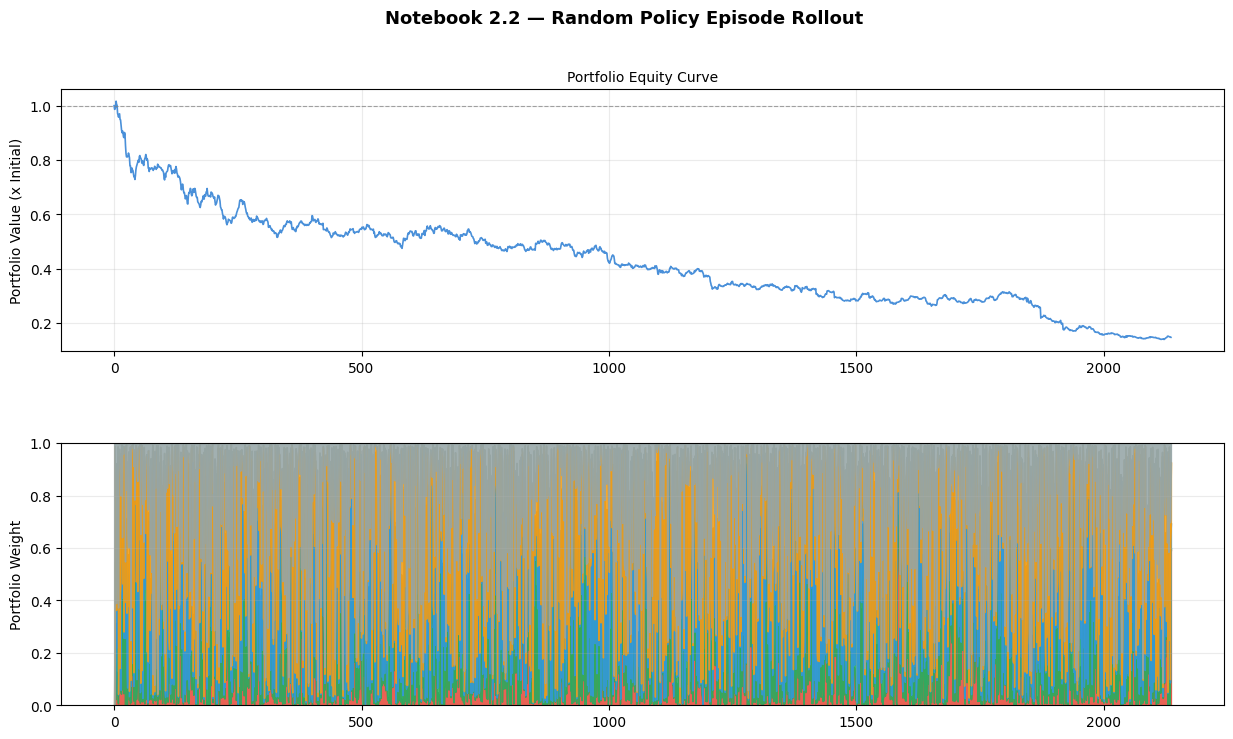

Cell 8 done: Visualization saved -> ../model_artifacts\env_random_rollout_v2.png


In [8]:
# CELL 8: RANDOM ROLLOUT VISUALIZATION
obs, _ = train_env.reset()
done = False
while not done:
    action = train_env.action_space.sample()
    obs, reward, terminated, truncated, info = train_env.step(action)
    done = terminated or truncated

pv_arr = np.array(train_env.portfolio_values)
wt_arr = np.array(train_env.weight_history)
T_ep   = len(pv_arr)

ASSET_LABELS = [t.replace('.NS', '') for t in TICKERS] + ['CASH']
COLORS = ['#E74C3C', '#27AE60', '#3498DB', '#F39C12', '#95A5A6']

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.35)
fig.suptitle("Notebook 2.2 — Random Policy Episode Rollout", fontsize=13, fontweight='bold')

ax1 = fig.add_subplot(gs[0])
ax1.plot(pv_arr / INITIAL_BALANCE, color='#4A90D9', linewidth=1.2, label='Random Policy')
ax1.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_ylabel("Portfolio Value (x Initial)")
ax1.set_title("Portfolio Equity Curve", fontsize=10)
ax1.grid(True, alpha=0.25)

ax2 = fig.add_subplot(gs[1])
bottom = np.zeros(T_ep)
for i, (label, color) in enumerate(zip(ASSET_LABELS, COLORS)):
    ax2.fill_between(range(T_ep), bottom, bottom + wt_arr[:, i], label=label, color=color, alpha=0.88)
    bottom += wt_arr[:, i]
ax2.set_ylabel("Portfolio Weight")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.25)

save_path = os.path.join(ART_DIR, "env_random_rollout_v2.png")
plt.savefig(save_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Cell 8 done: Visualization saved -> {save_path}")